# Project 27 — Heat Stress & Thermal Comfort Phenotyping with Unsupervised Learning

## Real wearable physiology + environmental clustering

This project upgrades the original K-Means exercise into a complete unsupervised-learning case study using the **Heatstroke Prevention Challenge / thermal-comfort dataset**.

The challenge data includes physiological signals/features collected with **Empatica E4 wearables**, environmental conditions, activity/task information, PMV thermal sensation, and personal thermal-assessment labels. The clustering model **does not use the personal thermal-assessment label during training**; labels are only used afterwards for interpretation and external validation.

### Business / research question

Can we discover meaningful **thermal-response phenotypes** from wearable physiology and environmental conditions without telling the algorithm the participant's subjective thermal-comfort label?

### What this notebook demonstrates

- robust data auditing and cleaning
- leakage-aware unsupervised feature selection
- missing-value handling and robust scaling
- K-Means model selection using multiple metrics
- cluster stability across random seeds
- PCA visualisation
- hierarchical clustering, Gaussian Mixtures and DBSCAN comparison
- cluster profiling and physiological interpretation
- participant/task/temperature segmentation
- external validation using labels **after** clustering
- anomaly / outlier scoring
- reusable inference pipeline
- reproducibility and integrity checks

> This is a research/portfolio analysis, not a medical diagnostic system and not a heatstroke clinical-risk score.

## 1. Imports and reproducibility

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    adjusted_mutual_info_score,
    normalized_mutual_info_score,
)
from sklearn.metrics import pairwise_distances
from sklearn.utils import resample

SEED = 42
RNG = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
warnings.filterwarnings("ignore")

print("Random seed:", SEED)

Random seed: 42


## 2. Load the real challenge dataset

The original notebook expected a local file called `heatstroke.csv`. This version searches sensible repository/Colab locations and fails clearly rather than silently generating synthetic data.

Download source / challenge information:
- Heatstroke Prevention Challenge: https://sites.google.com/view/heatstroke-challenge
- IEEE DataPort competition page: https://ieee-dataport.org/competitions/5th-abc-challenge-forecasting-thermal-comfort-sensations-heatstroke-prevention

In [2]:
CANDIDATE_PATHS = [
    Path("heatstroke.csv"),
    Path("data/heatstroke.csv"),
    Path("/content/heatstroke.csv"),
    Path("/content/drive/MyDrive/heatstroke.csv"),
]

DATA_PATH = next((p for p in CANDIDATE_PATHS if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "heatstroke.csv was not found. Download the original Heatstroke Prevention "
        "Challenge training data, save the relevant CSV as heatstroke.csv, and rerun."
    )

raw = pd.read_csv(DATA_PATH)

print("Loaded:", DATA_PATH)
print("Shape:", raw.shape)
display(raw.head())
display(raw.sample(min(5, len(raw)), random_state=SEED))

Loaded: heatstroke.csv
Shape: (81214, 69)


,id,datetime,num_ibis,hrv_mean_nni,hrv_median_nni,hrv_range_nni,hrv_sdsd,hrv_rmssd,hrv_nni_50,hrv_pnni_50,hrv_nni_20,hrv_pnni_20,hrv_cvsd,hrv_sdnn,hrv_cvnni,hrv_mean_hr,hrv_min_hr,hrv_max_hr,hrv_std_hr,hrv_total_power,hrv_vlf,hrv_lf,hrv_hf,hrv_lf_hf_ratio,hrv_lfnu,hrv_hfnu,hrv_SD1,hrv_SD2,hrv_SD2SD1,hrv_CSI,hrv_CVI,hrv_CSI_Modified,hrv_mean,hrv_std,hrv_min,hrv_max,hrv_ptp,hrv_sum,hrv_energy,hrv_skewness,hrv_kurtosis,hrv_peaks,hrv_rms,hrv_lineintegral,hrv_n_above_mean,hrv_n_below_mean,hrv_n_sign_changes,hrv_iqr,hrv_iqr_5_95,hrv_pct_5,hrv_pct_95,hrv_entropy,hrv_perm_entropy,hrv_svd_entropy,experiment,subject,Task,Room Color,Temperature,Humidity,PMV,PDD,Thermal sensation,Personal Thermal Assessment,Gender,Age,X_axis,Y_axis,Z_axis
0,1,2021-06-22 08:30:40+00:00,101,831.683168,765.625,1187.5,333.768287,333.768434,78.0,77.227723,91.0,90.099010,0.401317,253.538254,0.304850,77.998815,37.281553,142.222222,20.875105,28327.59517,2371.135187,9785.693839,16170.76614,0.605147,37.700418,62.299582,237.198793,268.886640,1.133592,1.133592,6.008802,1219.230916,831.683168,252.279992,421.875,1609.375,1187.5,84000.00,76289550.78,1.262270,1.378903,29.0,869.104186,23343.750,39.0,62.0,0,250.00000,921.8750,531.25000,1453.12500,4.572689,0.999700,0.654199,Experiment 8,Kawasaki,Typing,Orange,27,60,0.66,14.3,slightly warm,neutral,M,20,-40.96875,-21.75000,44.56250
1,1,2021-06-22 08:30:41+00:00,102,834.558824,765.625,1187.5,333.552878,333.564502,79.0,77.450980,92.0,90.196078,0.399690,253.946200,0.304288,77.756997,37.281553,142.222222,20.914202,28367.49444,2338.746707,9425.326334,16603.42140,0.567674,36.211217,63.788783,237.033856,269.800475,1.138236,1.138236,6.009973,1228.386483,834.558824,252.698300,421.875,1609.375,1187.5,85125.00,77555175.78,1.224890,1.268597,29.0,871.977557,23656.250,40.0,62.0,0,261.71875,917.1875,532.03125,1449.21875,4.582562,0.999926,0.657089,Experiment 8,Kawasaki,Typing,Orange,27,60,0.66,14.3,slightly warm,neutral,M,20,-43.34375,-22.78125,41.34375
2,1,2021-06-22 08:30:42+00:00,102,834.558824,765.625,1187.5,333.552878,333.564502,79.0,77.450980,92.0,90.196078,0.399690,253.946200,0.304288,77.756997,37.281553,142.222222,20.914202,28367.49444,2338.746707,9425.326334,16603.42140,0.567674,36.211217,63.788783,237.033856,269.800475,1.138236,1.138236,6.009973,1228.386483,834.558824,252.698300,421.875,1609.375,1187.5,85125.00,77555175.78,1.224890,1.268597,29.0,871.977557,23656.250,40.0,62.0,0,261.71875,917.1875,532.03125,1449.21875,4.582562,0.999926,0.657089,Experiment 8,Kawasaki,Typing,Orange,27,60,0.66,14.3,slightly warm,neutral,M,20,-44.84375,-24.31250,39.62500
3,1,2021-06-22 08:30:43+00:00,101,834.467822,765.625,1187.5,334.756609,334.787275,78.0,77.227723,91.0,90.099010,0.401199,255.211101,0.305837,77.822798,37.281553,142.222222,21.006974,28566.01994,2376.921417,9696.115649,16492.98287,0.587893,37.023480,62.976520,237.901163,271.419323,1.140891,1.140891,6.014157,1238.639578,834.467822,253.944537,421.875,1609.375,1187.5,84281.25,76843261.72,1.219969,1.228606,29.0,872.252471,23484.375,39.0,62.0,0,265.62500,921.8750,531.25000,1453.12500,4.572286,0.999700,0.656106,Experiment 8,Kawasaki,Typing,Orange,27,60,0.66,14.3,slightly warm,neutral,M,20,-44.03125,-23.68750,40.68750
4,1,2021-06-22 08:30:44+00:00,101,834.467822,765.625,1187.5,334.756609,334.787275,78.0,77.227723,91.0,90.099010,0.401199,255.211101,0.305837,77.822798,37.281553,142.222222,21.006974,28566.01994,2376.921417,9696.115649,16492.98287,0.587893,37.023480,62.976520,237.901163,271.419323,1.140891,1.140891,6.014157,1238.639578,834.467822,253.944537,421.875,1609.375,1187.5,84281.25,76843261.72,1.219969,1.228606,29.0,872.252471,23484.375,39.0,62.0,0,265.62500,921.8750,531.25000,1453.12500,4.572286,0.999700,0.656106,Experiment 8,Kawasaki,Typing,Orange,27,60,0.66,14.3,slightly warm,neutral,M,20,-43.96875,-22.96875,41.09375


,id,datetime,num_ibis,hrv_mean_nni,hrv_median_nni,hrv_range_nni,hrv_sdsd,hrv_rmssd,hrv_nni_50,hrv_pnni_50,hrv_nni_20,hrv_pnni_20,hrv_cvsd,hrv_sdnn,hrv_cvnni,hrv_mean_hr,hrv_min_hr,hrv_max_hr,hrv_std_hr,hrv_total_power,hrv_vlf,hrv_lf,hrv_hf,hrv_lf_hf_ratio,hrv_lfnu,hrv_hfnu,hrv_SD1,hrv_SD2,hrv_SD2SD1,hrv_CSI,hrv_CVI,hrv_CSI_Modified,hrv_mean,hrv_std,hrv_min,hrv_max,hrv_ptp,hrv_sum,hrv_energy,hrv_skewness,hrv_kurtosis,hrv_peaks,hrv_rms,hrv_lineintegral,hrv_n_above_mean,hrv_n_below_mean,hrv_n_sign_changes,hrv_iqr,hrv_iqr_5_95,hrv_pct_5,hrv_pct_95,hrv_entropy,hrv_perm_entropy,hrv_svd_entropy,experiment,subject,Task,Room Color,Temperature,Humidity,PMV,PDD,Thermal sensation,Personal Thermal Assessment,Gender,Age,X_axis,Y_axis,Z_axis
62179,1,2021-08-19 06:43:58+00:00,274,713.389599,695.3125,1281.250,130.532405,130.533020,85.0,31.021898,166.0,60.583942,0.182976,102.768280,0.144056,85.414388,36.226415,160.000000,10.148003,4414.453143,650.345643,1515.166192,2248.941309,0.673724,40.253000,59.747000,92.469863,112.124766,1.212555,1.212555,5.219822,543.829645,713.389599,102.580575,375.000,1656.250,1281.250,195468.750,142328613.3,4.203941,31.706362,80.0,720.727059,17796.875,102.0,172.0,0,62.50,203.1250,625.00000,828.12500,5.604105,0.989277,0.439629,Experiment 4,Yushi,Reading,Red,32,80,1.84,69.0,warm,slightly warm,M,20,27.00000,25.37500,51.9375
60966,1,2021-08-19 06:28:04+00:00,261,671.575671,640.6250,703.125,117.654457,117.663297,117.0,44.827586,182.0,69.731801,0.175205,93.121411,0.138661,90.687590,49.870130,120.000000,10.051638,3722.877139,921.070791,711.270902,2090.535446,0.340234,25.386155,74.613845,83.354716,101.956784,1.223168,1.223168,5.133466,498.840919,671.575671,92.942847,500.000,1203.125,703.125,175281.250,119969238.3,2.702300,10.730326,76.0,677.976588,19312.500,96.0,165.0,0,93.75,187.5000,593.75000,781.25000,5.555833,0.984294,0.416918,Experiment 3,Anna,Reading,Green,25,60,0.06,5.1,neutral,neutral,F,30,-64.09375,12.15625,-4.0625
1032,1,2021-06-22 08:38:35+00:00,144,891.927083,921.8750,1015.625,227.152083,227.154211,111.0,77.083333,129.0,89.583333,0.254678,168.949595,0.189421,70.386831,42.666667,153.600000,17.424449,10798.253240,1760.056109,3898.774370,5139.422760,0.758602,43.136638,56.863362,161.185352,176.372373,1.094221,1.094221,5.657876,771.961312,891.927083,168.361943,390.625,1406.250,1015.625,128437.500,118638671.9,-0.527049,0.823334,48.0,907.678173,24984.375,78.0,66.0,0,187.50,573.4375,549.21875,1122.65625,4.950921,0.998221,0.495852,Experiment 8,Okuma,Typing,Orange,27,60,0.66,14.3,slightly warm,neutral,F,40,35.34375,9.21875,51.3125
42952,1,2021-08-19 07:05:22+00:00,246,885.543699,906.2500,953.125,111.952200,111.954816,124.0,50.406504,187.0,76.016260,0.126425,101.722959,0.114871,68.688900,40.421053,112.941176,8.414227,5388.840012,1422.137742,1643.061808,2323.640461,0.707107,41.421354,58.578646,79.324211,120.011625,1.512926,1.512926,5.182749,726.274609,885.543699,101.515994,531.250,1484.375,953.125,217843.750,195445312.5,0.337022,4.776863,69.0,891.343447,17843.750,136.0,110.0,0,125.00,312.5000,703.12500,1015.62500,5.498747,0.999988,0.357224,Experiment 5,Hiroko,Reading,Orange,27,60,0.56,11.6,slightly warm,neutral,F,20,-5.18750,62.03125,16.8750
59465,1,2021-08-19 02:30:08+00:00,186,976.226478,984.3750,812.500,143.637062,143.637956,133.0,71.505376,165.0,88.709677,0.147136,121.294387,0.124248,62.587171,46.829268,128.000000,9.483018,6672.330849,1186.504298,2540.188731,2945.637819,0.862356,46.304576,53.695424,101.842363,138.031844,1.355348,1.355348,5.352028,748.324738,976.226478,120.967888,468.750,1281.250,812.500,181578.125,179983154.3,-0.663173,1.775053,56.0,983.692720,20500.000,100.0,86.0,0,125.00,375.0000,765.62500,1140.62500,5.217743,0.995148,0.384844,Experiment 3,Kitazima,Reading,Green,25,60,0.06,5.1,neutral,neutral,M,20,-49.53125,-34.56250,-23.3125


## 3. Standardise column names without destroying meaning

The challenge has appeared in slightly different exports. We preserve the raw frame and create a normalised working copy so the project can tolerate harmless spaces/case differences.

In [3]:
def normalise_name(name):
    name = str(name).strip().lower()
    for ch in [" ", "-", "/", "(", ")", "[", "]", "%", "."]:
        name = name.replace(ch, "_")
    while "__" in name:
        name = name.replace("__", "_")
    return name.strip("_")

data = raw.copy()
data.columns = [normalise_name(c) for c in data.columns]

print("Normalised columns:")
print(data.columns.tolist())

Normalised columns:
['id', 'datetime', 'num_ibis', 'hrv_mean_nni', 'hrv_median_nni', 'hrv_range_nni', 'hrv_sdsd', 'hrv_rmssd', 'hrv_nni_50', 'hrv_pnni_50', 'hrv_nni_20', 'hrv_pnni_20', 'hrv_cvsd', 'hrv_sdnn', 'hrv_cvnni', 'hrv_mean_hr', 'hrv_min_hr', 'hrv_max_hr', 'hrv_std_hr', 'hrv_total_power', 'hrv_vlf', 'hrv_lf', 'hrv_hf', 'hrv_lf_hf_ratio', 'hrv_lfnu', 'hrv_hfnu', 'hrv_sd1', 'hrv_sd2', 'hrv_sd2sd1', 'hrv_csi', 'hrv_cvi', 'hrv_csi_modified', 'hrv_mean', 'hrv_std', 'hrv_min', 'hrv_max', 'hrv_ptp', 'hrv_sum', 'hrv_energy', 'hrv_skewness', 'hrv_kurtosis', 'hrv_peaks', 'hrv_rms', 'hrv_lineintegral', 'hrv_n_above_mean', 'hrv_n_below_mean', 'hrv_n_sign_changes', 'hrv_iqr', 'hrv_iqr_5_95', 'hrv_pct_5', 'hrv_pct_95', 'hrv_entropy', 'hrv_perm_entropy', 'hrv_svd_entropy', 'experiment', 'subject', 'task', 'room_color', 'temperature', 'humidity', 'pmv', 'pdd', 'thermal_sensation', 'personal_thermal_assessment', 'gender', 'age', 'x_axis', 'y_axis', 'z_axis']


## 4. Data-quality audit

In [4]:
audit = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing": data.isna().sum(),
    "missing_pct": data.isna().mean().mul(100).round(2),
    "unique": data.nunique(dropna=True),
})
audit["constant"] = audit["unique"] <= 1

print("Rows:", len(data))
print("Columns:", data.shape[1])
print("Duplicate rows:", data.duplicated().sum())
print("Completely empty columns:", int(data.isna().all().sum()))
print("Constant columns:", int(audit["constant"].sum()))

display(audit.sort_values(["missing_pct", "unique"], ascending=[False, True]).head(30))

Rows: 81214
Columns: 69


Duplicate rows: 0
Completely empty columns: 0
Constant columns: 2


,dtype,missing,missing_pct,unique,constant
id,int64,0,0.0,1,True
hrv_n_sign_changes,int64,0,0.0,1,True
humidity,int64,0,0.0,2,False
gender,str,0,0.0,2,False
task,str,0,0.0,3,False
room_color,str,0,0.0,3,False
temperature,int64,0,0.0,3,False
age,int64,0,0.0,3,False
thermal_sensation,str,0,0.0,4,False
personal_thermal_assessment,str,0,0.0,5,False


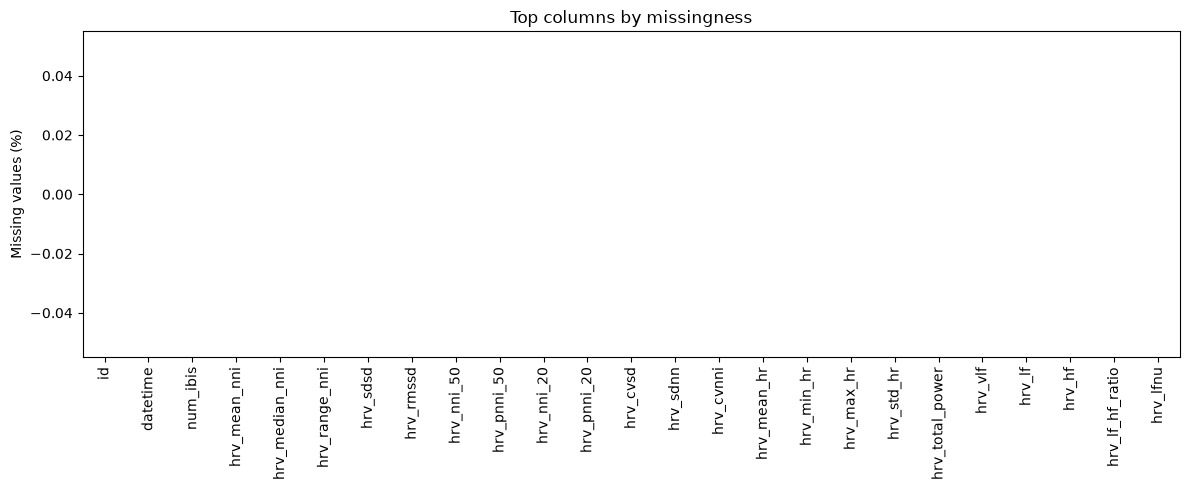

In [5]:
plt.figure(figsize=(12, 5))
missing = audit["missing_pct"].sort_values(ascending=False).head(25)
missing.plot(kind="bar")
plt.ylabel("Missing values (%)")
plt.title("Top columns by missingness")
plt.tight_layout()
plt.show()

## 5. Clean categorical formatting and timestamps

A published analysis of this challenge noted that some `experiment` values contained stray whitespace. We strip categorical strings globally and derive time features when a datetime field is available.

In [6]:
for col in data.select_dtypes(include="object").columns:
    data[col] = data[col].astype(str).str.strip()

datetime_candidates = [c for c in data.columns if "datetime" in c or c in {"timestamp", "time"}]

for col in datetime_candidates:
    parsed = pd.to_datetime(data[col], errors="coerce")
    if parsed.notna().mean() > 0.8:
        data[f"{col}_hour"] = parsed.dt.hour + parsed.dt.minute / 60
        data[f"{col}_dayofweek"] = parsed.dt.dayofweek
        data[f"{col}_minute_of_day"] = parsed.dt.hour * 60 + parsed.dt.minute
        print(f"Derived time features from: {col}")

Derived time features from: datetime


## 6. Identify semantic columns and prevent target leakage

The objective is **unsupervised phenotype discovery**. Therefore labels such as personal thermal assessment and PMV thermal sensation are excluded from the clustering matrix.

Identifiers such as participant ID and experiment ID are also excluded from distance calculations because arbitrary IDs should not determine physiological similarity.

In [7]:
TARGET_PATTERNS = [
    "personal_thermal_assessment",
    "personal_thermal",
    "thermal_assessment",
]

PMV_LABEL_PATTERNS = [
    "thermal_sensation",
    "pmv_label",
    "pmv_thermal",
]

ID_PATTERNS = [
    "subject",
    "participant",
    "person_id",
    "participant_id",
    "subject_id",
]

EXPERIMENT_PATTERNS = ["experiment"]

def first_matching_column(patterns):
    for pattern in patterns:
        for col in data.columns:
            if col == pattern or pattern in col:
                return col
    return None

target_col = first_matching_column(TARGET_PATTERNS)
pmv_label_col = first_matching_column(PMV_LABEL_PATTERNS)
subject_col = first_matching_column(ID_PATTERNS)
experiment_col = first_matching_column(EXPERIMENT_PATTERNS)

print("Personal assessment label:", target_col)
print("PMV / thermal label:", pmv_label_col)
print("Participant column:", subject_col)
print("Experiment column:", experiment_col)

Personal assessment label: personal_thermal_assessment
PMV / thermal label: thermal_sensation
Participant column: subject
Experiment column: experiment


## 7. Build a leakage-aware numerical feature matrix

We prioritise:
- HRV features
- heart-rate features
- EDA / electrodermal features
- temperature and humidity
- accelerometer features
- age and other genuinely numeric context variables

We remove labels, arbitrary IDs, constant columns and extremely sparse columns.

In [8]:
label_and_id_cols = {
    c for c in [target_col, pmv_label_col, subject_col, experiment_col]
    if c is not None
}

numeric_cols = data.select_dtypes(include=np.number).columns.tolist()

excluded_numeric = set()
for col in numeric_cols:
    low = col.lower()
    if any(token in low for token in [
        "label", "target", "assessment", "thermal_sensation",
        "subject", "participant", "experiment"
    ]):
        excluded_numeric.add(col)

candidate_features = [
    c for c in numeric_cols
    if c not in excluded_numeric
    and c not in label_and_id_cols
    and data[c].nunique(dropna=True) > 1
    and data[c].isna().mean() < 0.50
]

print("Candidate numeric features:", len(candidate_features))
print(candidate_features)

Candidate numeric features: 62
['num_ibis', 'hrv_mean_nni', 'hrv_median_nni', 'hrv_range_nni', 'hrv_sdsd', 'hrv_rmssd', 'hrv_nni_50', 'hrv_pnni_50', 'hrv_nni_20', 'hrv_pnni_20', 'hrv_cvsd', 'hrv_sdnn', 'hrv_cvnni', 'hrv_mean_hr', 'hrv_min_hr', 'hrv_max_hr', 'hrv_std_hr', 'hrv_total_power', 'hrv_vlf', 'hrv_lf', 'hrv_hf', 'hrv_lf_hf_ratio', 'hrv_lfnu', 'hrv_hfnu', 'hrv_sd1', 'hrv_sd2', 'hrv_sd2sd1', 'hrv_csi', 'hrv_cvi', 'hrv_csi_modified', 'hrv_mean', 'hrv_std', 'hrv_min', 'hrv_max', 'hrv_ptp', 'hrv_sum', 'hrv_energy', 'hrv_skewness', 'hrv_kurtosis', 'hrv_peaks', 'hrv_rms', 'hrv_lineintegral', 'hrv_n_above_mean', 'hrv_n_below_mean', 'hrv_iqr', 'hrv_iqr_5_95', 'hrv_pct_5', 'hrv_pct_95', 'hrv_entropy', 'hrv_perm_entropy', 'hrv_svd_entropy', 'temperature', 'humidity', 'pmv', 'pdd', 'age', 'x_axis', 'y_axis', 'z_axis', 'datetime_hour', 'datetime_dayofweek', 'datetime_minute_of_day']


In [9]:
# Remove almost-duplicate numerical features with extremely high correlation.
numeric_frame = data[candidate_features].copy()
corr = numeric_frame.corr(numeric_only=True).abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_to_drop = [
    column for column in upper.columns
    if any(upper[column] > 0.995)
]

features = [c for c in candidate_features if c not in high_corr_to_drop]

print("Dropped as near-duplicate (>0.995 |correlation|):", len(high_corr_to_drop))
print("Final clustering features:", len(features))

Dropped as near-duplicate (>0.995 |correlation|): 8
Final clustering features: 54


## 8. Robust preprocessing

Median imputation handles missing numeric values. Robust scaling reduces the effect of heavy-tailed HRV values and physiological outliers while keeping all rows available for clustering.

In [10]:
preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])

X = preprocessor.fit_transform(data[features])

# Full data are retained for final assignment, while expensive validation
# metrics use deterministic real-data samples so the notebook scales to
# the complete challenge CSV.
VALIDATION_SAMPLE_SIZE = min(8000, len(X))
COMPARISON_SAMPLE_SIZE = min(5000, len(X))
FIT_SAMPLE_SIZE = min(25000, len(X))

validation_idx = RNG.choice(len(X), size=VALIDATION_SAMPLE_SIZE, replace=False)
comparison_idx = RNG.choice(len(X), size=COMPARISON_SAMPLE_SIZE, replace=False)
fit_idx = RNG.choice(len(X), size=FIT_SAMPLE_SIZE, replace=False)

X_validation = X[validation_idx]
X_comparison = X[comparison_idx]
X_fit = X[fit_idx]

print("Feature matrix:", X.shape)
print("Finite values only:", np.isfinite(X).all())
print("Model-selection sample:", X_validation.shape)
print("Algorithm-comparison sample:", X_comparison.shape)
print("K-Means fitting sample:", X_fit.shape)

Feature matrix: (81214, 54)
Finite values only: True
Model-selection sample: (8000, 54)
Algorithm-comparison sample: (5000, 54)
K-Means fitting sample: (25000, 54)


## 9. Exploratory distributions

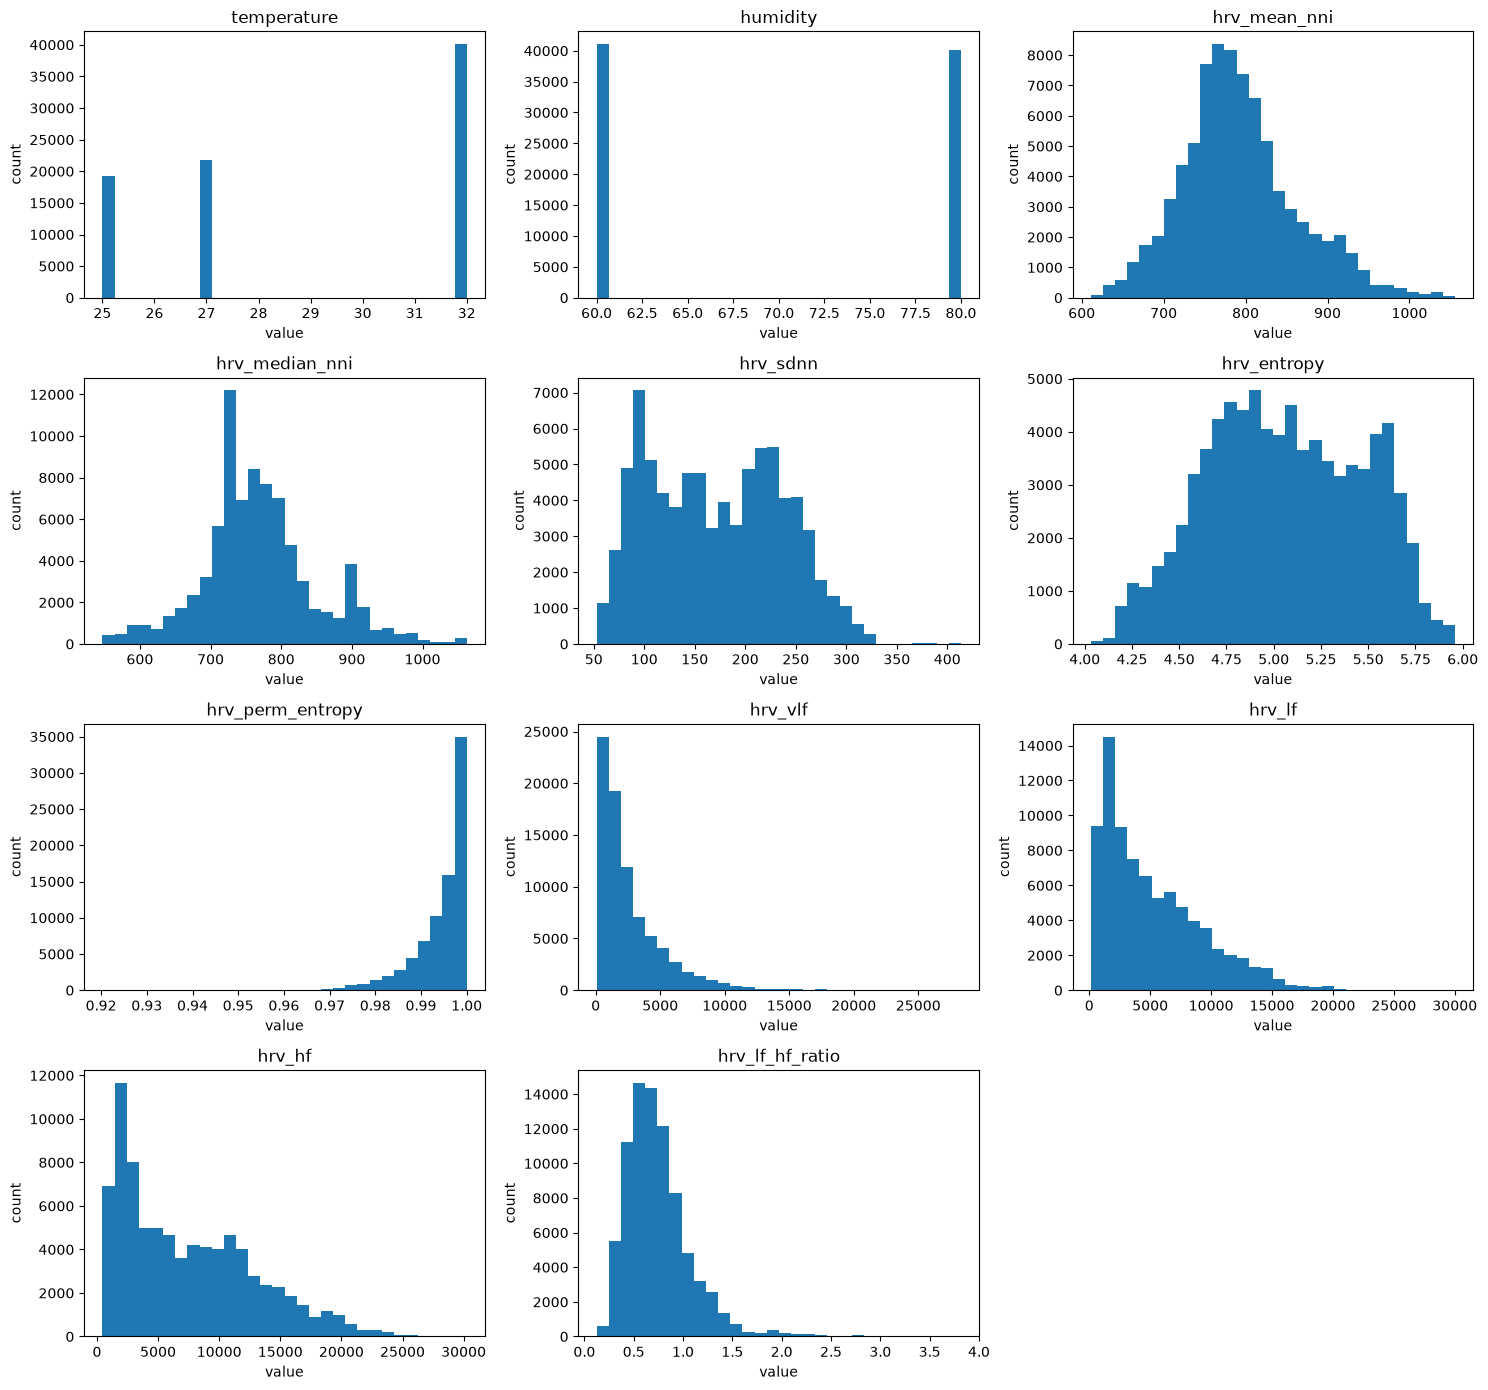

In [11]:
important_patterns = [
    "temperature", "humidity", "hrv", "heart", "eda",
    "rmssd", "sdnn", "entropy", "lf", "hf"
]

important_features = []
for pattern in important_patterns:
    matches = [c for c in features if pattern in c.lower()]
    important_features.extend(matches[:2])

important_features = list(dict.fromkeys(important_features))[:12]

if important_features:
    n = len(important_features)
    cols = 3
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3.5 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, col in zip(axes, important_features):
        ax.hist(data[col].dropna(), bins=30)
        ax.set_title(col)
        ax.set_xlabel("value")
        ax.set_ylabel("count")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No named HRV/environment feature patterns detected; using generic numerical features.")

## 10. PCA: inspect dimensional structure before clustering

PCA is used here for **visualisation and diagnostic interpretation**, not as proof that clusters exist.

,component,explained_variance,cumulative
0,1,0.4954,0.4954
1,2,0.1904,0.6858
2,3,0.0661,0.7519
3,4,0.0506,0.8025
4,5,0.0405,0.8430
5,6,0.0223,0.8653
6,7,0.0198,0.8851
7,8,0.0188,0.9039
8,9,0.0155,0.9195
9,10,0.0144,0.9338


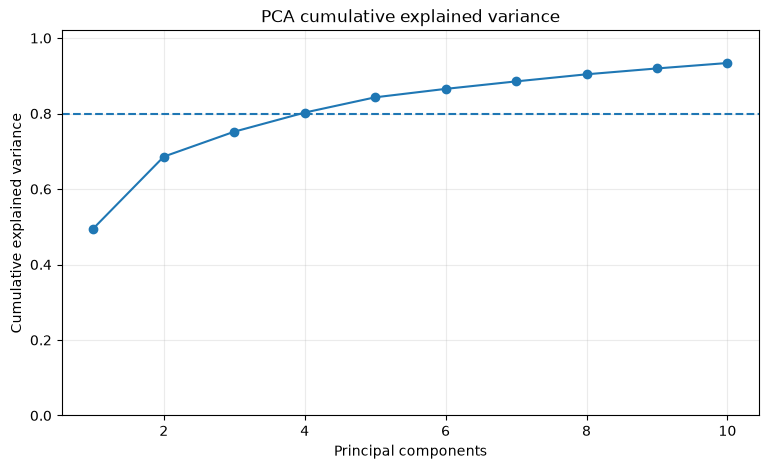

In [12]:
pca = PCA(n_components=min(10, X.shape[1]), random_state=SEED)
X_pca_full = pca.fit_transform(X)

explained = pd.DataFrame({
    "component": np.arange(1, len(pca.explained_variance_ratio_) + 1),
    "explained_variance": pca.explained_variance_ratio_,
})
explained["cumulative"] = explained["explained_variance"].cumsum()

display(explained.round(4))

plt.figure(figsize=(9, 5))
plt.plot(explained["component"], explained["cumulative"], marker="o")
plt.axhline(0.80, linestyle="--")
plt.ylabel("Cumulative explained variance")
plt.xlabel("Principal components")
plt.title("PCA cumulative explained variance")
plt.ylim(0, 1.02)
plt.grid(alpha=0.25)
plt.show()

## 11. K-Means model selection using multiple internal metrics

We do **not** choose K only from an elbow plot. For K=2…10 we compare:
- inertia (lower is better)
- silhouette score (higher is better)
- Calinski-Harabasz score (higher is better)
- Davies-Bouldin score (lower is better)

In [13]:
k_rows = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=30,
        random_state=SEED,
    )
    labels = model.fit_predict(X_validation)

    k_rows.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_validation, labels),
        "calinski_harabasz": calinski_harabasz_score(X_validation, labels),
        "davies_bouldin": davies_bouldin_score(X_validation, labels),
    })

k_eval = pd.DataFrame(k_rows)
display(k_eval.round(4))

best_k_silhouette = int(k_eval.loc[k_eval["silhouette"].idxmax(), "k"])
best_k_db = int(k_eval.loc[k_eval["davies_bouldin"].idxmin(), "k"])

print("Best K by silhouette:", best_k_silhouette)
print("Best K by Davies-Bouldin:", best_k_db)

,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,241170.4131,0.5117,6102.2631,0.8900
1,3,188149.0503,0.2726,5037.2676,1.2765
2,4,159100.0546,0.2889,4457.4715,1.2097
3,5,146752.3627,0.2451,3792.1135,1.4562
4,6,137104.1426,0.2386,3359.2786,1.3942
5,7,127617.5542,0.1944,3106.1470,1.4654
6,8,119646.4308,0.1950,2915.4961,1.5420
7,9,114206.8042,0.1942,2719.8067,1.6209
8,10,110194.5687,0.1918,2537.6430,1.6298


Best K by silhouette: 2
Best K by Davies-Bouldin: 2


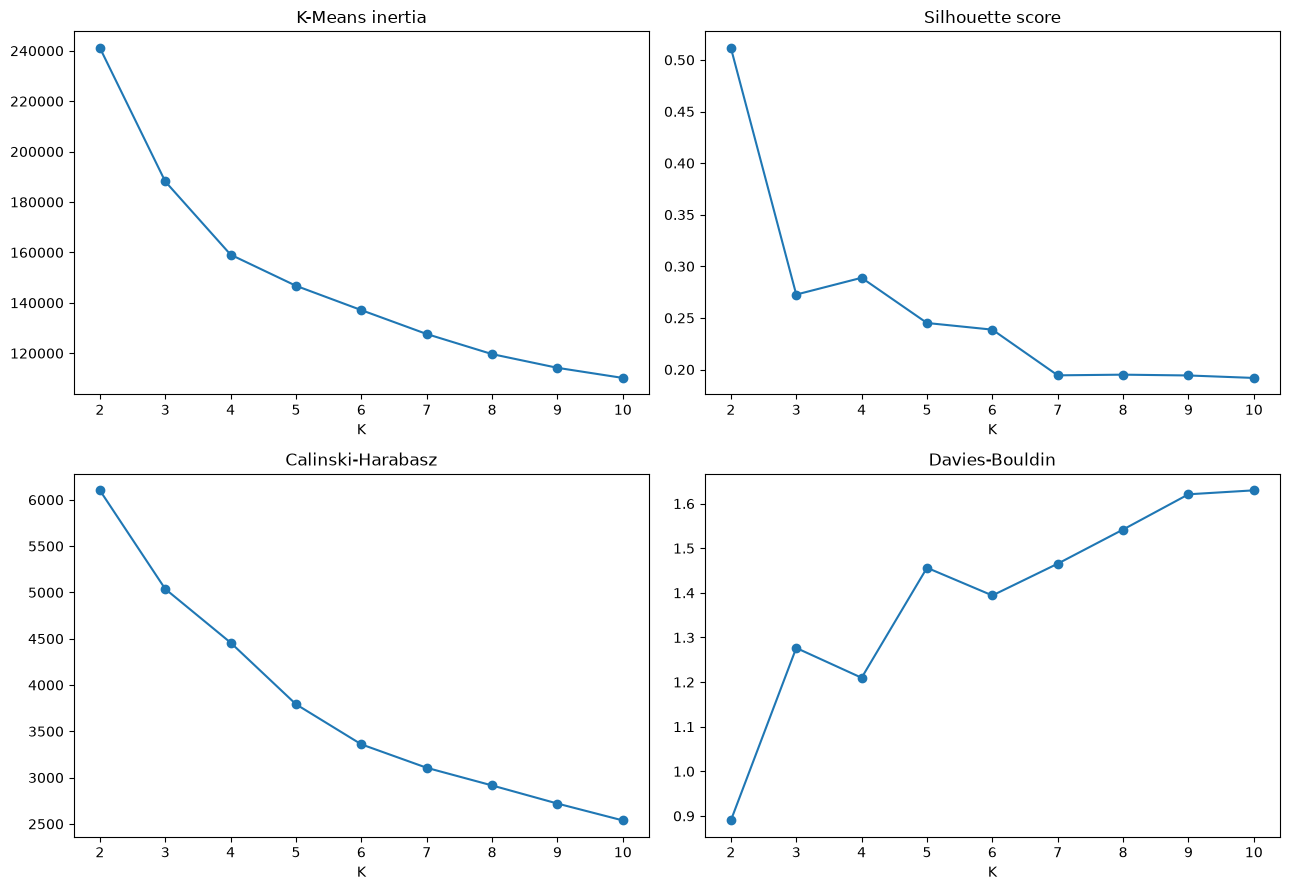

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(k_eval["k"], k_eval["inertia"], marker="o")
axes[0, 0].set_title("K-Means inertia")
axes[0, 0].set_xlabel("K")

axes[0, 1].plot(k_eval["k"], k_eval["silhouette"], marker="o")
axes[0, 1].set_title("Silhouette score")
axes[0, 1].set_xlabel("K")

axes[1, 0].plot(k_eval["k"], k_eval["calinski_harabasz"], marker="o")
axes[1, 0].set_title("Calinski-Harabasz")
axes[1, 0].set_xlabel("K")

axes[1, 1].plot(k_eval["k"], k_eval["davies_bouldin"], marker="o")
axes[1, 1].set_title("Davies-Bouldin")
axes[1, 1].set_xlabel("K")

plt.tight_layout()
plt.show()

## 12. Cluster-stability analysis

A clustering solution should not collapse when the K-Means random seed changes. We quantify stability with **Adjusted Rand Index (ARI)** between the reference solution and repeated fits.

In [15]:
SELECTED_K = best_k_silhouette

reference = KMeans(
    n_clusters=SELECTED_K,
    n_init=50,
    random_state=SEED,
).fit(X_validation)

reference_labels = reference.labels_

stability_rows = []
for seed in range(20):
    model = KMeans(
        n_clusters=SELECTED_K,
        n_init=20,
        random_state=seed,
    ).fit(X_validation)

    stability_rows.append({
        "seed": seed,
        "ARI_vs_reference": adjusted_rand_score(reference_labels, model.labels_),
        "inertia": model.inertia_,
    })

stability = pd.DataFrame(stability_rows)

display(stability.round(4))
print("Mean ARI stability:", round(stability["ARI_vs_reference"].mean(), 4))
print("Minimum ARI stability:", round(stability["ARI_vs_reference"].min(), 4))

,seed,ARI_vs_reference,inertia
0,0,1.0,241170.4131
1,1,1.0,241170.4131
2,2,1.0,241170.4131
3,3,1.0,241170.4131
4,4,1.0,241170.4131
5,5,1.0,241170.4131
6,6,1.0,241170.4131
7,7,1.0,241170.4131
8,8,1.0,241170.4131
9,9,1.0,241170.4131


Mean ARI stability: 1.0
Minimum ARI stability: 1.0


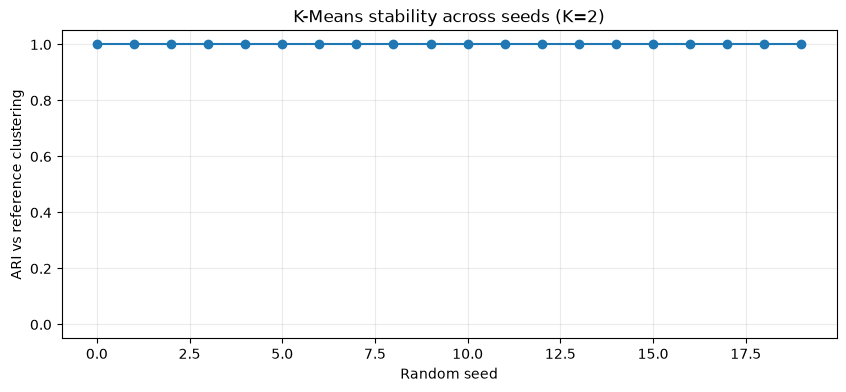

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(stability["seed"], stability["ARI_vs_reference"], marker="o")
plt.ylim(-0.05, 1.05)
plt.xlabel("Random seed")
plt.ylabel("ARI vs reference clustering")
plt.title(f"K-Means stability across seeds (K={SELECTED_K})")
plt.grid(alpha=0.25)
plt.show()

## 13. Fit the final K-Means model

In [17]:
final_kmeans = KMeans(
    n_clusters=SELECTED_K,
    init="k-means++",
    n_init=100,
    random_state=SEED,
)

final_kmeans.fit(X_fit)
cluster = final_kmeans.predict(X)

results = data.copy()
results["cluster"] = cluster

print("Selected K:", SELECTED_K)
validation_labels = final_kmeans.predict(X_validation)
print("Final silhouette (validation sample):", round(silhouette_score(X_validation, validation_labels), 4))
print("Final Calinski-Harabasz (validation sample):", round(calinski_harabasz_score(X_validation, validation_labels), 2))
print("Final Davies-Bouldin (validation sample):", round(davies_bouldin_score(X_validation, validation_labels), 4))
print()
print("Cluster sizes:")
display(results["cluster"].value_counts().sort_index().rename("rows").to_frame())

Selected K: 2


Final silhouette (validation sample): 0.5117
Final Calinski-Harabasz (validation sample): 6102.26
Final Davies-Bouldin (validation sample): 0.89

Cluster sizes:


,rows
cluster,
0,12602
1,68612


## 14. PCA cluster map

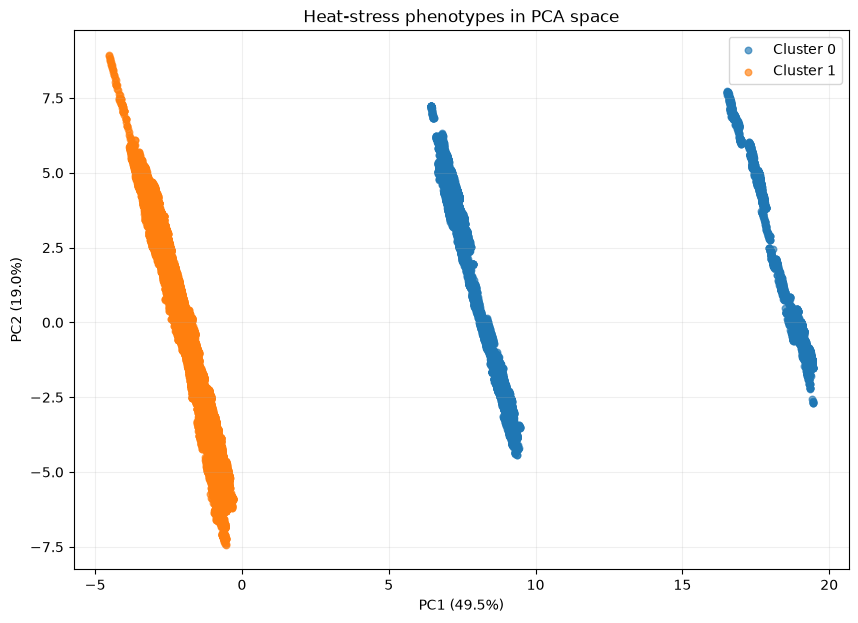

In [18]:
pca2 = PCA(n_components=2, random_state=SEED)
X2 = pca2.fit_transform(X)

plt.figure(figsize=(10, 7))
for c in sorted(np.unique(cluster)):
    mask = cluster == c
    plt.scatter(
        X2[mask, 0],
        X2[mask, 1],
        s=22,
        alpha=0.65,
        label=f"Cluster {c}",
    )

plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")
plt.title("Heat-stress phenotypes in PCA space")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 15. Cluster profiles in original feature units

We compare cluster medians so HRV and environmental variables remain interpretable.

In [19]:
profile_features = important_features if important_features else features[:12]

cluster_profile = (
    results.groupby("cluster")[profile_features]
    .median(numeric_only=True)
    .round(3)
)

display(cluster_profile)

,temperature,humidity,hrv_mean_nni,hrv_median_nni,hrv_sdnn,hrv_entropy,hrv_perm_entropy,hrv_vlf,hrv_lf,hrv_hf,hrv_lf_hf_ratio
cluster,,,,,,,,,,,
0,32.0,80.0,798.113,781.250,119.062,5.375,0.994,921.327,1738.089,3019.600,0.644
1,27.0,60.0,783.854,765.625,177.636,5.001,0.997,1900.074,4415.284,6866.527,0.700


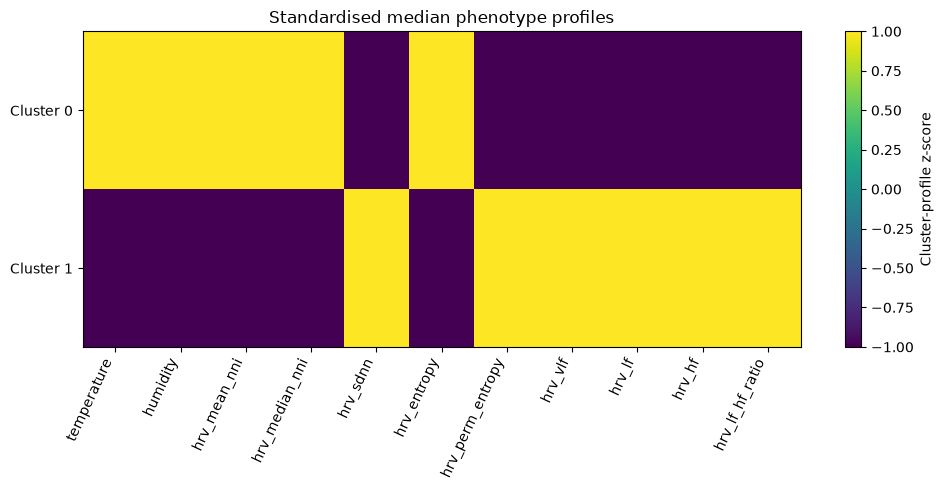

In [20]:
# Standardised cluster profile heatmap without seaborn.
profile_scaled = cluster_profile.copy()
for col in profile_scaled.columns:
    std = profile_scaled[col].std(ddof=0)
    if std > 0:
        profile_scaled[col] = (
            profile_scaled[col] - profile_scaled[col].mean()
        ) / std
    else:
        profile_scaled[col] = 0

fig, ax = plt.subplots(figsize=(max(10, 0.8 * len(profile_scaled.columns)), 5))
im = ax.imshow(profile_scaled.values, aspect="auto")
ax.set_xticks(range(len(profile_scaled.columns)))
ax.set_xticklabels(profile_scaled.columns, rotation=65, ha="right")
ax.set_yticks(range(len(profile_scaled.index)))
ax.set_yticklabels([f"Cluster {i}" for i in profile_scaled.index])
ax.set_title("Standardised median phenotype profiles")
plt.colorbar(im, ax=ax, label="Cluster-profile z-score")
plt.tight_layout()
plt.show()

## 16. Environmental and activity interpretation

These variables are used for **post-hoc profiling**. A cluster associated with hotter temperatures or heavier activity should not automatically be called “high heatstroke risk”; it is a discovered data segment that requires scientific/clinical validation.

In [21]:
context_cols = []

for token in ["temperature", "humidity", "task", "activity", "age", "gender"]:
    context_cols.extend([c for c in results.columns if token in c.lower()])

context_cols = list(dict.fromkeys(context_cols))

for col in context_cols:
    print("\n###", col)
    if pd.api.types.is_numeric_dtype(results[col]):
        display(
            results.groupby("cluster")[col]
            .agg(["count", "mean", "median", "std"])
            .round(3)
        )
    else:
        display(
            pd.crosstab(
                results["cluster"],
                results[col],
                normalize="index"
            ).round(3)
        )


### temperature


,count,mean,median,std
cluster,,,,
0,12602,29.490,32.0,2.939
1,68612,28.905,27.0,3.064



### humidity


,count,mean,median,std
cluster,,,,
0,12602,71.322,80.0,9.913
1,68612,69.616,60.0,9.993



### task


task,Radio,Reading,Typing
cluster,,,
0,0.167,0.556,0.276
1,0.193,0.535,0.273



### age


,count,mean,median,std
cluster,,,,
0,12602,32.746,30.0,4.463
1,68612,20.000,20.0,0.000



### gender


gender,F,M
cluster,,
0,0.763,0.237
1,0.331,0.669


## 17. Participant-level cluster distribution

This checks whether a cluster is dominated by one participant rather than reflecting a repeatable phenotype across people.

Participants: 16


cluster,0,1
subject,,
Anna,1.0,0.0
Dan,0.0,1.0
Enomoto,0.0,1.0
Hikari,0.0,1.0
Hiroko,0.0,1.0
Kawasaki,0.0,1.0
Kazuki Imural,0.0,1.0
Kitazima,0.0,1.0
Kyoka Chan,0.0,1.0


<Figure size 1200x600 with 0 Axes>

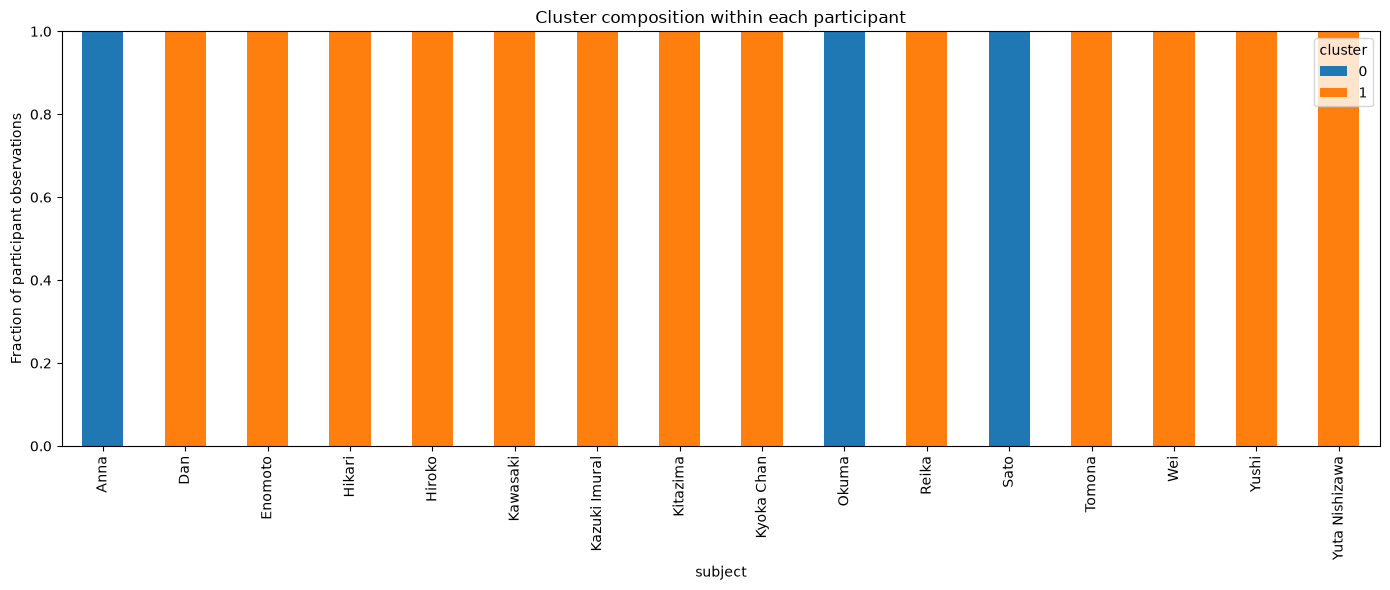

In [22]:
if subject_col is not None:
    participant_mix = pd.crosstab(
        results[subject_col],
        results["cluster"],
        normalize="index",
    )

    print("Participants:", participant_mix.shape[0])
    display(participant_mix.head(20).round(3))

    plt.figure(figsize=(12, 6))
    participant_mix.plot(
        kind="bar",
        stacked=True,
        figsize=(14, 6),
        legend=True,
    )
    plt.ylabel("Fraction of participant observations")
    plt.title("Cluster composition within each participant")
    plt.tight_layout()
    plt.show()
else:
    print("No participant/subject column was detected.")

## 18. External validation against subjective thermal assessment

This section is intentionally **after** clustering.

Adjusted Mutual Information (AMI), Normalized Mutual Information (NMI), and ARI measure association between discovered clusters and known labels. They are **not classification accuracy**, and the model was not trained to reproduce these labels.

In [23]:
if target_col is not None:
    labelled_mask = results[target_col].notna()

    target_codes, target_names = pd.factorize(results.loc[labelled_mask, target_col])

    external = {
        "adjusted_mutual_information": adjusted_mutual_info_score(
            target_codes,
            results.loc[labelled_mask, "cluster"],
        ),
        "normalized_mutual_information": normalized_mutual_info_score(
            target_codes,
            results.loc[labelled_mask, "cluster"],
        ),
        "adjusted_rand_index": adjusted_rand_score(
            target_codes,
            results.loc[labelled_mask, "cluster"],
        ),
    }

    print(json.dumps(external, indent=2))

    label_mix = pd.crosstab(
        results.loc[labelled_mask, "cluster"],
        results.loc[labelled_mask, target_col],
        normalize="index",
    )

    display(label_mix.round(3))
else:
    print("No personal thermal-assessment label detected; external validation skipped.")

{
  "adjusted_mutual_information": 0.00881896872977542,
  "normalized_mutual_information": 0.008849674568673615,
  "adjusted_rand_index": -0.02703177728035589
}


personal_thermal_assessment,hot,neutral,slightly warm,very hot,warm
cluster,,,,,
0,0.057,0.654,0.218,0.000,0.071
1,0.057,0.567,0.224,0.033,0.118


## 19. Compare different clustering families

K-Means assumes roughly spherical clusters. We compare it with:
- Agglomerative clustering
- Gaussian Mixture Models
- DBSCAN

This comparison uses internal validation only and avoids cherry-picking a method because it happens to match the subjective label.

In [24]:
comparison_rows = []

def add_cluster_metrics(name, labels):
    labels = np.asarray(labels)
    unique = np.unique(labels)

    # Exclude DBSCAN noise (-1) for internal metric calculation.
    valid = labels != -1
    valid_labels = labels[valid]

    if valid.sum() < 3 or len(np.unique(valid_labels)) < 2:
        return

    comparison_rows.append({
        "model": name,
        "clusters": len(np.unique(valid_labels)),
        "noise_fraction": float(np.mean(labels == -1)),
        "silhouette": silhouette_score(X_comparison[valid], valid_labels),
        "calinski_harabasz": calinski_harabasz_score(X_comparison[valid], valid_labels),
        "davies_bouldin": davies_bouldin_score(X_comparison[valid], valid_labels),
    })

kmeans_comparison_labels = final_kmeans.predict(X_comparison)
add_cluster_metrics("KMeans", kmeans_comparison_labels)

agg = AgglomerativeClustering(n_clusters=SELECTED_K)
agg_labels = agg.fit_predict(X_comparison)
add_cluster_metrics("Agglomerative", agg_labels)

gmm = GaussianMixture(
    n_components=SELECTED_K,
    covariance_type="full",
    random_state=SEED,
    n_init=5,
)
gmm_labels = gmm.fit_predict(X_comparison)
add_cluster_metrics("GaussianMixture", gmm_labels)

for eps in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]:
    db = DBSCAN(eps=eps, min_samples=max(5, int(np.sqrt(len(X)) / 3)))
    db_labels = db.fit_predict(X_comparison)
    add_cluster_metrics(f"DBSCAN eps={eps}", db_labels)

model_comparison = pd.DataFrame(comparison_rows)
display(
    model_comparison
    .sort_values("silhouette", ascending=False)
    .round(4)
)

,model,clusters,noise_fraction,silhouette,calinski_harabasz,davies_bouldin
0,KMeans,2,0.0,0.5144,3820.8473,0.8844
1,Agglomerative,2,0.0,0.5144,3820.8473,0.8844
2,GaussianMixture,2,0.0,0.5125,3784.4775,0.8907


## 20. Cluster-confidence / distance analysis

K-Means does not output probabilities, but distance to the assigned centroid is useful for:
- finding ambiguous points
- identifying unusual physiological observations
- selecting representative examples near cluster centres

In [25]:
centroid_distances = pairwise_distances(X, final_kmeans.cluster_centers_)
assigned_distance = centroid_distances[np.arange(len(X)), cluster]

results["distance_to_centroid"] = assigned_distance
results["cluster_distance_percentile"] = (
    results.groupby("cluster")["distance_to_centroid"]
    .rank(pct=True)
)

print("Distance summary:")
display(
    results.groupby("cluster")["distance_to_centroid"]
    .describe()
    .round(3)
)

Distance summary:


,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,12602.0,6.618,1.906,3.682,5.147,5.915,8.370,13.167
1,68612.0,4.953,1.409,2.154,3.925,4.855,5.754,15.315


In [26]:
# Representative observations = closest rows to each centroid.
representatives = (
    results.sort_values("distance_to_centroid")
    .groupby("cluster", as_index=False)
    .head(3)
)

show_cols = [
    c for c in [
        subject_col,
        experiment_col,
        target_col,
        pmv_label_col,
        *context_cols,
        "cluster",
        "distance_to_centroid",
    ]
    if c is not None and c in representatives.columns
]

display(representatives[show_cols].head(3 * SELECTED_K))

,subject,experiment,personal_thermal_assessment,thermal_sensation,temperature,humidity,task,age,gender,cluster,distance_to_centroid
68062,Kyoka Chan,Experiment 8,warm,slightly warm,27,60,Typing,20,F,1,2.154323
68061,Kyoka Chan,Experiment 8,warm,slightly warm,27,60,Typing,20,F,1,2.160009
68060,Kyoka Chan,Experiment 8,warm,slightly warm,27,60,Typing,20,F,1,2.160694
10460,Sato,Experiment 4,slightly warm,warm,32,80,Reading,30,M,0,3.681779
10461,Sato,Experiment 4,slightly warm,warm,32,80,Reading,30,M,0,3.691250
10462,Sato,Experiment 4,slightly warm,warm,32,80,Reading,30,M,0,3.702589


## 21. Potential outliers

Rows above the 99th percentile of within-cluster centroid distance are flagged for inspection. They are **not automatically bad data**; they may represent rare but legitimate physiological responses.

In [27]:
outlier_thresholds = (
    results.groupby("cluster")["distance_to_centroid"]
    .quantile(0.99)
    .to_dict()
)

results["potential_outlier"] = [
    d > outlier_thresholds[c]
    for d, c in zip(results["distance_to_centroid"], results["cluster"])
]

print("Potential outliers:", int(results["potential_outlier"].sum()))
print("Outlier percentage:", round(results["potential_outlier"].mean() * 100, 2), "%")

display(
    results.loc[results["potential_outlier"], show_cols]
    .head(20)
)

Potential outliers: 814
Outlier percentage: 1.0 %


,subject,experiment,personal_thermal_assessment,thermal_sensation,temperature,humidity,task,age,gender,cluster,distance_to_centroid
2876,Okuma,Experiment 6,neutral,warm,32,80,Reading,40,F,0,11.432720
2877,Okuma,Experiment 6,neutral,warm,32,80,Reading,40,F,0,11.473064
2878,Okuma,Experiment 6,neutral,warm,32,80,Reading,40,F,0,11.435869
2879,Okuma,Experiment 6,neutral,warm,32,80,Reading,40,F,0,11.473483
2880,Okuma,Experiment 6,neutral,warm,32,80,Reading,40,F,0,11.459563
2881,Okuma,Experiment 6,neutral,warm,32,80,Reading,40,F,0,11.459214
2882,Okuma,Experiment 6,neutral,warm,32,80,Reading,40,F,0,11.215906
2889,Okuma,Experiment 6,neutral,warm,32,80,Reading,40,F,0,10.819917
2893,Okuma,Experiment 6,neutral,warm,32,80,Reading,40,F,0,10.915188
6730,Okuma,Experiment 5,neutral,slightly warm,27,60,Reading,40,F,0,10.832138


## 22. Bootstrap stability of the selected solution

Random seeds test optimisation stability. Bootstrap resampling asks a different question: do similar cluster centres appear when the observed dataset changes slightly?

In [28]:
bootstrap_inertias = []
bootstrap_silhouettes = []

for i in range(15):
    idx = RNG.integers(0, len(X_comparison), size=len(X_comparison))
    X_boot = X_comparison[idx]

    model = KMeans(
        n_clusters=SELECTED_K,
        n_init=20,
        random_state=SEED + i,
    ).fit(X_boot)

    labels_boot = model.labels_

    bootstrap_inertias.append(model.inertia_)
    if len(np.unique(labels_boot)) > 1:
        bootstrap_silhouettes.append(
            silhouette_score(X_boot, labels_boot)
        )

print("Bootstrap runs:", len(bootstrap_inertias))
print(
    "Bootstrap silhouette mean ± SD:",
    round(np.mean(bootstrap_silhouettes), 4),
    "±",
    round(np.std(bootstrap_silhouettes), 4),
)

Bootstrap runs: 15
Bootstrap silhouette mean ± SD: 0.5149 ± 0.0046


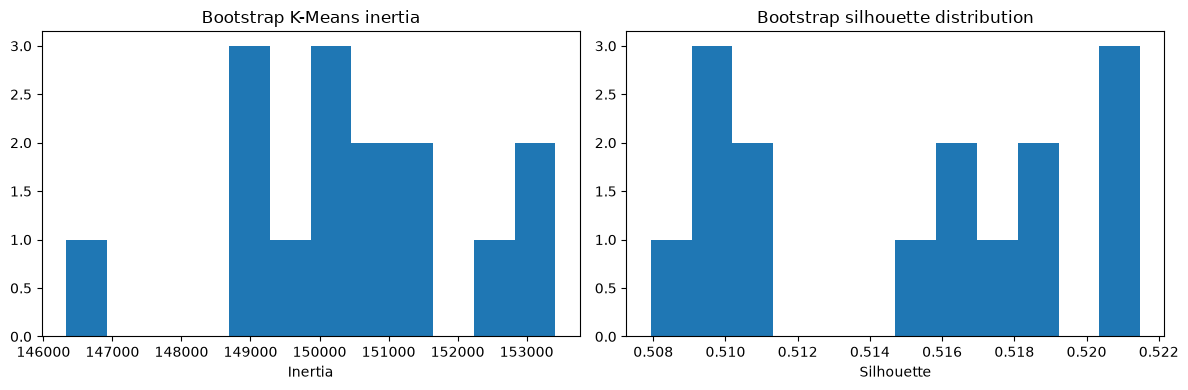

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(bootstrap_inertias, bins=12)
axes[0].set_title("Bootstrap K-Means inertia")
axes[0].set_xlabel("Inertia")

axes[1].hist(bootstrap_silhouettes, bins=12)
axes[1].set_title("Bootstrap silhouette distribution")
axes[1].set_xlabel("Silhouette")

plt.tight_layout()
plt.show()

## 23. Reusable inference function

This turns the notebook into a small analytical component rather than a one-off experiment. New rows must contain the same selected numerical features.

In [30]:
def assign_thermal_phenotype(new_frame):
    """
    Assign K-Means phenotype to new observations.

    Important:
    - This is an unsupervised cluster assignment, not a diagnosis.
    - Input columns must include the fitted feature set.
    """
    missing = [c for c in features if c not in new_frame.columns]
    if missing:
        raise ValueError(f"Missing required features: {missing[:10]}")

    X_new = preprocessor.transform(new_frame[features])
    labels = final_kmeans.predict(X_new)
    d = final_kmeans.transform(X_new)
    confidence_proxy = d[np.arange(len(X_new)), labels]

    return pd.DataFrame({
        "cluster": labels,
        "distance_to_centroid": confidence_proxy,
    }, index=new_frame.index)

demo_assignments = assign_thermal_phenotype(data.head(5))
display(demo_assignments)

,cluster,distance_to_centroid
0,1,4.456851
1,1,4.484497
2,1,4.486412
3,1,4.504185
4,1,4.503466


## 24. Integrity checks

In [31]:
assert len(cluster) == len(data)
assert X.shape[0] == len(data)
assert np.isfinite(X).all()
assert len(np.unique(cluster)) == SELECTED_K
assert set(label_and_id_cols).isdisjoint(features)
assert target_col not in features if target_col is not None else True
assert pmv_label_col not in features if pmv_label_col is not None else True
assert stability["ARI_vs_reference"].between(-1, 1).all()

print("All clustering integrity checks passed ✅")

All clustering integrity checks passed ✅


## 25. Final project summary

This project is stronger than the original two-variable K-Means exercise because it treats clustering as a complete modelling problem:

1. **Real-world data provenance:** wearable physiology, HRV, environment, activity and subjective assessments from the Heatstroke Prevention Challenge.
2. **Leakage control:** personal thermal-assessment and PMV labels are excluded from unsupervised training.
3. **Model selection:** K is selected using silhouette, Calinski-Harabasz, Davies-Bouldin and inertia instead of a single elbow plot.
4. **Robustness:** repeated-seed and bootstrap stability checks.
5. **Model comparison:** K-Means vs hierarchical clustering vs Gaussian Mixtures vs DBSCAN.
6. **Explainability:** cluster profiles in the original feature units plus representative observations.
7. **External validation:** labels are used only after clustering via AMI/NMI/ARI—not misleading classification accuracy.
8. **Operationalisation:** reusable phenotype-assignment function and outlier monitoring.

### Interview-ready explanation

> “I used wearable HRV and environmental data to discover latent thermal-response phenotypes. I deliberately removed subjective thermal labels from model training, selected the number of clusters using multiple internal validation metrics, tested stability across seeds and bootstraps, compared alternative clustering families, then used known thermal assessments only for post-hoc external validation and interpretation.”

### Limitations

- Clusters are statistical segments, **not clinical heatstroke categories**.
- K-Means depends on the chosen feature representation and distance metric.
- Repeated measurements from the same participant introduce dependence.
- Participant-disjoint validation is required before any personalised deployment claim.
- Sensor artefacts, missingness and activity context can affect HRV-derived features.
- A future version should use the official train/test participant split and compare unsupervised phenotypes with supervised thermal-comfort forecasting.

**Suggested CV bullet:**  
Built an end-to-end unsupervised thermal-physiology analytics pipeline on wearable HRV/environment data, using robust preprocessing, K-Means model selection, PCA, cluster stability, hierarchical/GMM/DBSCAN benchmarking, phenotype profiling, external label validation and anomaly detection.